# Recyclable Waste Material Classification

The dataset used can be found on the Hugging Face website at https://huggingface.co/datasets/garythung/trashnet/tree/main .

A GitHub repository by the original creator of the dataset is on https://github.com/garythung/trashnet .

To download the dataset locally, go to the 'Files and Versions' tab and click the download button next to 'dataset-original.zip'. The zip file will need to be uploaded to your Drive to load on this notebook.

This notebook includes code modified from https://github.com/nachi-hebbar/Transfer-Learning-ResNet-Keras and  https://github.com/KamiriTech/Loading-and-Pre-processing-Image-Datasets-in-Google-colab-

### Data Preprocessing

In [12]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
import tf_keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [13]:
# Splitting data into training and validation sets with 20% for validation.
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="training",
        seed=123)
ds_validation = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="validation",
        seed=123)

Found 2529 files belonging to 6 classes.
Found 2529 files belonging to 6 classes.
Using 2024 files for training.
Found 2529 files belonging to 6 classes.
Using 505 files for validation.


In [14]:
# Define batch size and print labels

batch_size = 32

dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [23]:
# Improved data preprocessing
def preprocess_data(image, label):
    # Resize to standard ResNet input size
    image = tf.image.resize(image, [224, 224])
    # Normalize to [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

    # Add data augmentation for training
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    return image, label

# Apply preprocessing and augmentation
ds_train_processed = ds_train.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
ds_train_processed = ds_train_processed.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

# Only preprocess validation data (no augmentation)
ds_validation_processed = ds_validation.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

In [24]:
# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
ds_train_processed = ds_train_processed.cache().prefetch(buffer_size=AUTOTUNE)
ds_validation_processed = ds_validation_processed.cache().prefetch(buffer_size=AUTOTUNE)

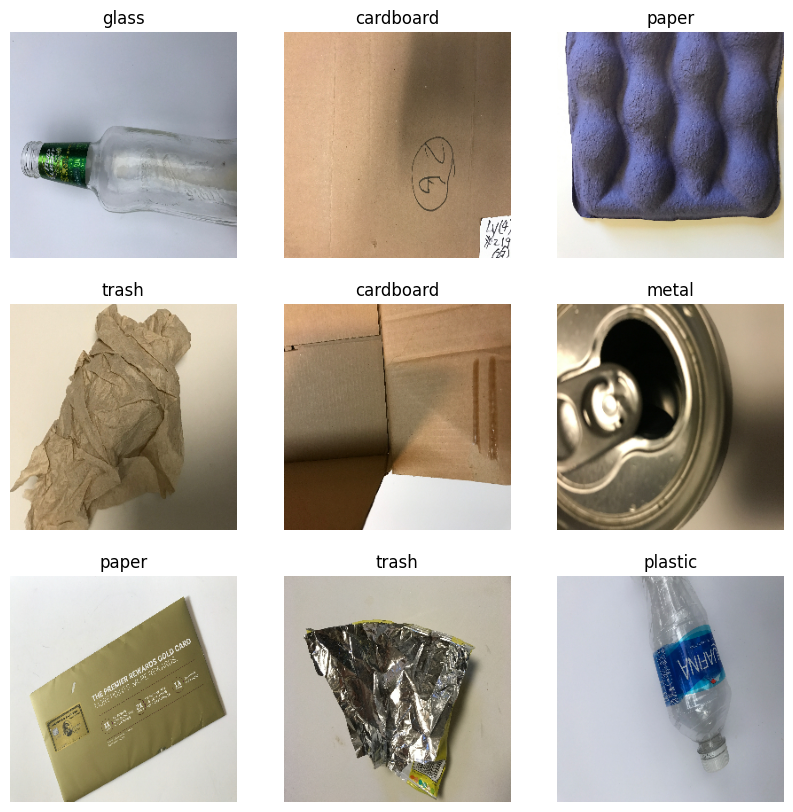

In [25]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

## Testing pre-trained ResNet-50 model

In [26]:
# Improved model architecture
def create_improved_model(num_classes=6):
    # Load pretrained ResNet50
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        pooling=None
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Add custom head
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

In [27]:
# Create improved model
improved_model, base_model = create_improved_model(len(class_names))

### Stage 1: Train only the custom head

In [28]:
# Stage 1: Train only the custom head
print("Stage 1: Training custom head with frozen ResNet...")
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Stage 1: Training custom head with frozen ResNet...


In [29]:
# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [30]:
# Train stage 1
history_stage1 = improved_model.fit(
    ds_train_processed,
    validation_data=ds_validation_processed,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print(f"Stage 1 - Best validation accuracy: {max(history_stage1.history['val_accuracy']):.4f}")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.2979 - loss: 2.0460 - val_accuracy: 0.2614 - val_loss: 1.7587 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3904 - loss: 1.7141 - val_accuracy: 0.2099 - val_loss: 1.8248 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4087 - loss: 1.5446 - val_accuracy: 0.2317 - val_loss: 1.8449 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 977ms/step - accuracy: 0.4370 - loss: 1.5224 - val_accuracy: 0.2574 - val_loss: 1.7683 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.4730 - loss: 1.3845 - val_accuracy: 0.2653 - val_loss: 1.7446 - learning_rate: 5.0000e-04
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 872ms/step - accuracy: 0.4858 - loss: 1.3020 - val_accuracy: 0.2535 - val_loss: 1.6441 - learning_rate: 5.0000e-04
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 867ms/step - accuracy: 0.4876 - loss: 1.3

### Stage 2: Fine-tune last layers of ResNet

In [31]:
base_model.trainable = True

In [32]:
# Fine-tune from this layer onwards
fine_tune_at = 140  # About last 30 layers

# Freeze all layers before fine_tune_at
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [33]:
# Use lower learning rate for fine-tuning
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
# Train stage 2

history_stage2 = improved_model.fit(
    ds_train_processed,
    validation_data=ds_validation_processed,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.3406 - loss: 1.9428 - val_accuracy: 0.1683 - val_loss: 5.7583 - learning_rate: 1.0000e-04
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4183 - loss: 1.6028 - val_accuracy: 0.1842 - val_loss: 4.2197 - learning_rate: 1.0000e-04
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.4411 - loss: 1.4357 - val_accuracy: 0.3327 - val_loss: 2.6517 - learning_rate: 1.0000e-04
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.4662 - loss: 1.3710 - val_accuracy: 0.3485 - val_loss: 2.0091 - learning_rate: 1.0000e-04
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5356 - loss: 1.2542 - val_accuracy: 0.2990 - val_loss: 1.9844 - learning_rate: 1.0000e-04
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5474 - loss: 1.1429 - val_accuracy: 0.3663 - val_loss: 1.6078 - learning_rate: 1.0000e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.6034 - los

In [35]:
print(f"Stage 2 - Best validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")

Stage 2 - Best validation accuracy: 0.4475


In [36]:
# Combine training histories
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return combined

combined_history = combine_histories(history_stage1, history_stage2)

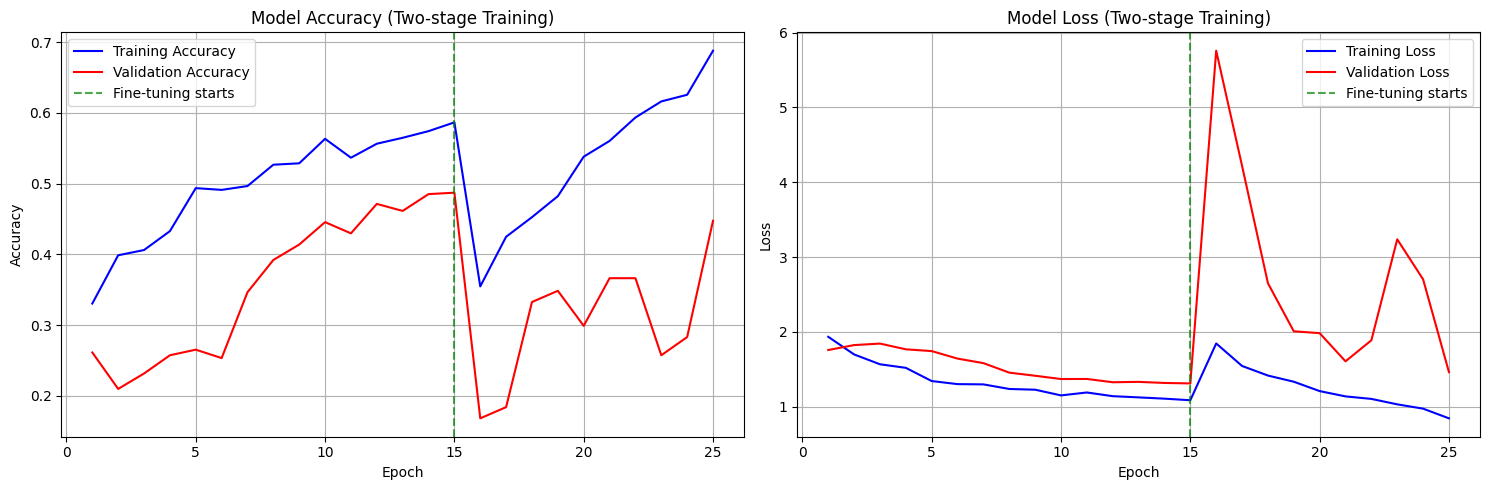

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot with stage separation
epochs_stage1 = len(history_stage1.history['accuracy'])
total_epochs = len(combined_history['accuracy'])

ax1.plot(range(1, total_epochs + 1), combined_history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(range(1, total_epochs + 1), combined_history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.axvline(x=epochs_stage1, color='g', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax1.set_title('Model Accuracy (Two-stage Training)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(range(1, total_epochs + 1), combined_history['loss'], 'b-', label='Training Loss')
ax2.plot(range(1, total_epochs + 1), combined_history['val_loss'], 'r-', label='Validation Loss')
ax2.axvline(x=epochs_stage1, color='g', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax2.set_title('Model Loss (Two-stage Training)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# Final evaluation
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

final_train_acc = combined_history['accuracy'][-1]
final_val_acc = combined_history['val_accuracy'][-1]
best_val_acc = max(combined_history['val_accuracy'])

print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


FINAL MODEL EVALUATION
Final Training Accuracy: 0.6877 (68.77%)
Final Validation Accuracy: 0.4475 (44.75%)
Best Validation Accuracy: 0.4871 (48.71%)


In [42]:
# Check for overfitting
if final_train_acc - final_val_acc > 0.15:
    print("\n⚠️  WARNING: Possible overfitting detected!")
    print("   Consider: More dropout, data augmentation, or regularization")
elif final_val_acc < 0.5:
    print("\n⚠️  WARNING: Low accuracy detected!")
    print("   Consider: Check data quality, increase model capacity, or more training")
else:
    print(f"\n✅ Model looks good! Validation accuracy improved significantly.")


⚠️  WARNING: Possible overfitting detected!
   Consider: More dropout, data augmentation, or regularization


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [45]:
# Get predictions on validation set
print("Making predictions on validation set...")
y_pred_probs = improved_model.predict(ds_validation_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

Making predictions on validation set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step   


In [46]:
# Get true labels from validation dataset
y_true = []
for images, labels in ds_validation_processed:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Number of predictions: {len(y_pred)}")
print(f"Number of true labels: {len(y_true)}")

Number of predictions: 505
Number of true labels: 505


In [49]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.4475 (44.75%)
Precision (weighted): 0.4917
Recall (weighted): 0.4475
F1-Score (weighted): 0.4260
Error Rate: 0.5525 (55.25%)


In [51]:
# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard       0.43      0.73      0.54        83
       glass       0.38      0.60      0.47       105
       metal       0.42      0.49      0.45        77
       paper       0.80      0.29      0.43       123
     plastic       0.47      0.31      0.37        90
       trash       0.00      0.00      0.00        27

    accuracy                           0.45       505
   macro avg       0.42      0.41      0.38       505
weighted avg       0.49      0.45      0.43       505




CONFUSION MATRIX
Raw confusion matrix:
[[61 13  3  3  3  0]
 [13 63 19  0 10  0]
 [ 6 24 38  3  5  1]
 [41 24 11 36 11  0]
 [19 29 12  1 28  1]
 [ 3 11  8  2  3  0]]


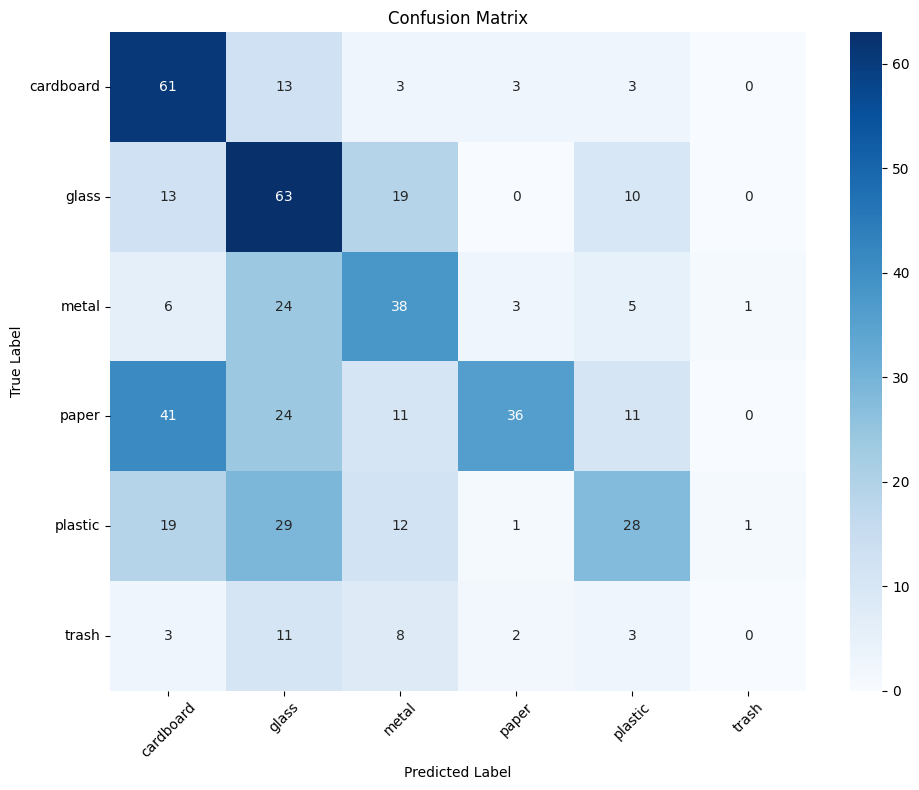

In [50]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print("Raw confusion matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### ignore leftover testing from colab

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import streamlit as st


@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('/content/final_model.hdf5')
  return model
with st.spinner('Model is being loaded..'):
  model=load_model()

st.write("""
         # Recyclable Waste Classification
         """
         )

file = st.file_uploader("Please upload an image file", type=["jpg", "png"])

from PIL import Image, ImageOps

st.set_option('deprecation.showfileUploaderEncoding', False)
def import_and_predict(image_data, model):

        size = (180,180)
        image = ImageOps.fit(image_data, size, Image.ANTIALIAS)
        image = np.asarray(image)
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #img_resize = (cv2.resize(img, dsize=(75, 75),    interpolation=cv2.INTER_CUBIC))/255.

        img_reshape = img[np.newaxis,...]

        prediction = model.predict(img_reshape)

        return prediction
if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, use_column_width=True)
    predictions = import_and_predict(image, model)
    score = tf.nn.softmax(predictions[0])
    st.write(prediction)
    st.write(score)
    print(
    "This image is most likely {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
!pip install pyngrok

In [ ]:
!ngrok authtoken #Insert Authentication Token here, obtained from Ngrok